<a href="https://colab.research.google.com/github/fai-algethami/secom-quality-analysis/blob/main/SECOM_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

104 failed runs
0.06636885768985322 failure rate
144 sensors removed
446 sensors kept
0 missing values left

Yield: 93.4%  |  Failure rate: 6.6%


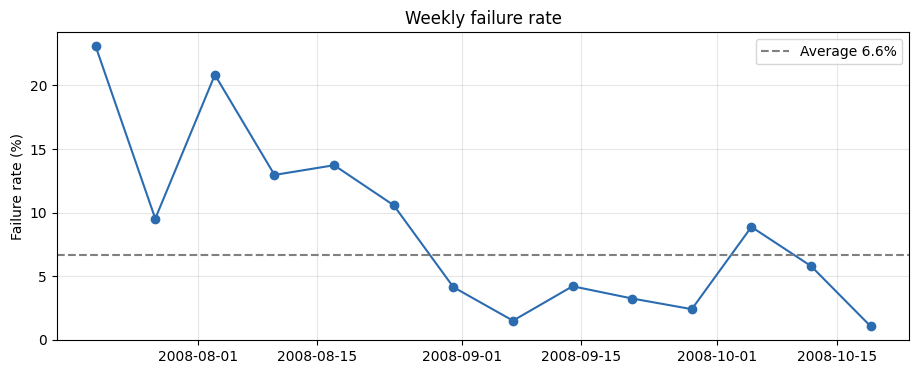

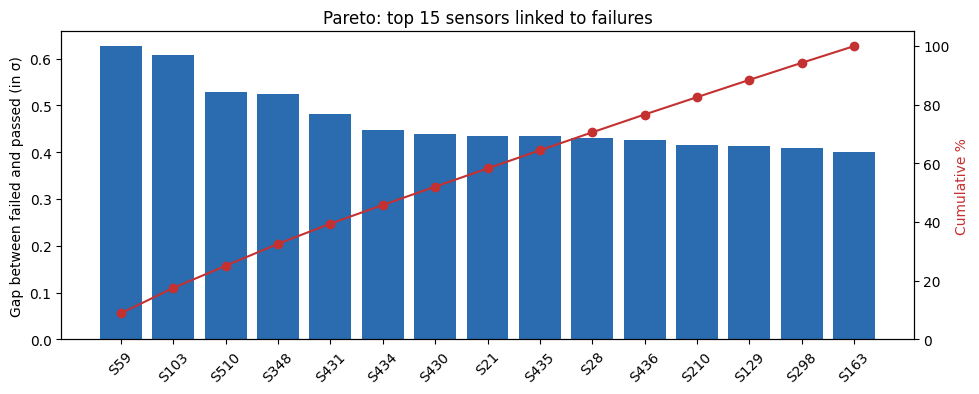

Key sensors: ['S59', 'S103', 'S510']


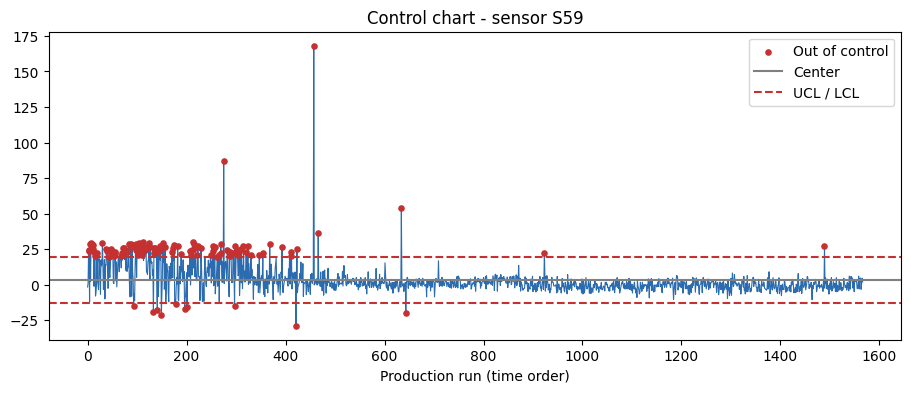

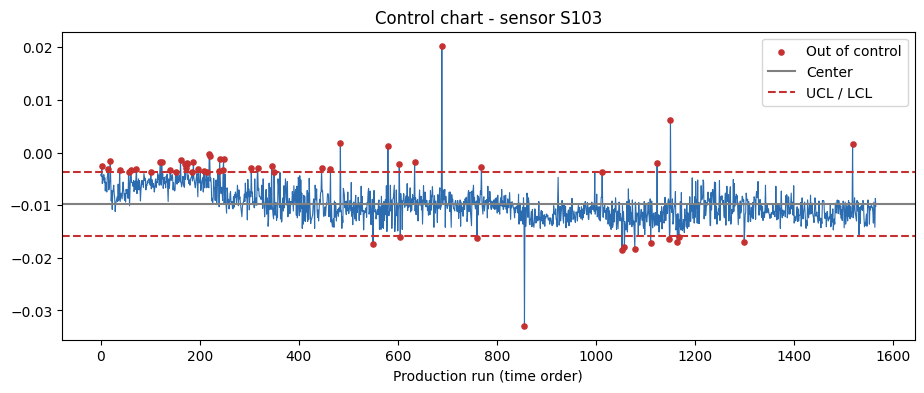

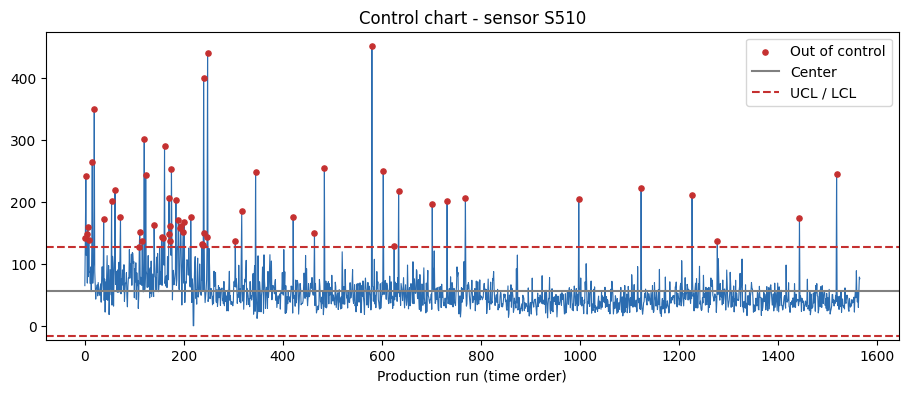

  sensor  out_of_control_runs  fail_rate_out  fail_rate_in
0    S59                  129           13.2           6.1
1   S103                   56           14.3           6.4
2   S510                   57           19.3           6.2 

  sensor  Cpk_first_half  Cpk_second_half
0    S59            0.65             1.69
1   S103            0.70             0.54
2   S510            0.37             0.44 

KEY FINDINGS
1. Line yield: 93.4% (104 failed runs out of 1567).
2. 144 of 590 sensors were unusable (mostly empty or constant).
3. Sensors most linked to failures: S59, S103, S510.
4. S59 was out of control in 129 runs: failure rate 13.2% when out of control vs 6.1% in control.

RECOMMENDATIONS
- Monitor S59, S103, S510 with real-time control charts and alarms.
- Investigate root causes of out-of-control runs (equipment, recipe, material).
- Repair data collection for sensors with mostly missing readings.


In [ ]:
# ===== PART 1: Load & Clean Data =====
import pandas as pd
import matplotlib.pyplot as plt

link = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/"
readings = pd.read_csv(link + "secom.data", sep=r"\s+", header=None)

labels = pd.read_csv(link + "secom_labels.data", sep=" ", header=None, quotechar='"', names=["result", "timestamp"])
labels["fail"] = (labels["result"] == 1).astype(int)
labels["timestamp"] = pd.to_datetime(labels["timestamp"], format="%d/%m/%Y %H:%M:%S")

print(labels["fail"].sum(), "failed runs")
print(labels["fail"].mean(), "failure rate")

df = pd.concat([labels[["timestamp", "fail"]], readings], axis=1)

sensors = df.columns[2:]
missing = df[sensors].isna().mean()

empty = missing[missing > 0.5].index
constant = df[sensors].nunique() <= 1
bad = empty.union(constant[constant].index)
keep = [s for s in sensors if s not in bad]
print(len(bad), "sensors removed")
print(len(keep), "sensors kept")

df[keep] = df[keep].fillna(df[keep].median())
print(df[keep].isna().sum().sum(), "missing values left")


# ===== PART 2: Weekly Failure Rate =====
fail_rate = df["fail"].mean()
print(f"\nYield: {1 - fail_rate:.1%}  |  Failure rate: {fail_rate:.1%}")

weekly = df.set_index("timestamp")["fail"].resample("W").agg(["mean", "count"])
weekly = weekly[weekly["count"] >= 10]   # ignore weeks with very few runs

plt.figure(figsize=(11, 4))
plt.plot(weekly.index, weekly["mean"] * 100, marker="o", color="#2b6cb0")
plt.axhline(fail_rate * 100, color="gray", linestyle="--", label=f"Average {fail_rate:.1%}")
plt.title("Weekly failure rate")
plt.ylabel("Failure rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ===== PART 3: Pareto - Which sensors are linked to failures? =====
passed = df[df["fail"] == 0][keep]
failed = df[df["fail"] == 1][keep]

gap = ((failed.mean() - passed.mean()) / df[keep].std()).abs()
top = gap.sort_values(ascending=False).head(15)
cumulative = top.cumsum() / top.sum() * 100
names = ["S" + str(s) for s in top.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(names, top.values, color="#2b6cb0")
ax.set_ylabel("Gap between failed and passed (in σ)")
ax.set_title("Pareto: top 15 sensors linked to failures")
ax.tick_params(axis="x", rotation=45)
ax2 = ax.twinx()
ax2.plot(names, cumulative.values, color="#c53030", marker="o")
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative %", color="#c53030")
plt.show()

key_sensors = list(top.index[:3])
print("Key sensors:", ["S" + str(s) for s in key_sensors])


# ===== PART 4: Control Charts (I-chart) =====
results = []
for s in key_sensors:
    x = df[s]
    sigma = x.diff().abs().mean() / 1.128     # standard SPC estimate of variation
    center = x.mean()
    ucl = center + 3 * sigma                  # upper control limit
    lcl = center - 3 * sigma                  # lower control limit
    out = (x > ucl) | (x < lcl)               # True = out of control

    plt.figure(figsize=(11, 4))
    plt.plot(df.index, x, color="#2b6cb0", linewidth=0.8)
    plt.scatter(df.index[out], x[out], color="#c53030", s=14, zorder=3, label="Out of control")
    plt.axhline(center, color="gray", label="Center")
    plt.axhline(ucl, color="#c53030", linestyle="--", label="UCL / LCL")
    plt.axhline(lcl, color="#c53030", linestyle="--")
    plt.title(f"Control chart - sensor S{s}")
    plt.xlabel("Production run (time order)")
    plt.legend(loc="upper right")
    plt.show()

    results.append({
        "sensor": f"S{s}",
        "out_of_control_runs": int(out.sum()),
        "fail_rate_out": round(df["fail"][out].mean() * 100, 1) if out.any() else None,
        "fail_rate_in": round(df["fail"][~out].mean() * 100, 1),
    })

spc = pd.DataFrame(results)
print(spc, "\n")


# ===== PART 5: Process Capability (Cpk) & Findings =====
half = len(df) // 2
first = df.iloc[:half]
second = df.iloc[half:]

def cpk(x, lsl, usl):
    return min(usl - x.mean(), x.mean() - lsl) / (3 * x.std())

rows = []
for s in key_sensors:
    # Assumed spec limits: range of passing runs in the first half (0.5% - 99.5%)
    ref = first[first["fail"] == 0][s]
    lsl, usl = ref.quantile(0.005), ref.quantile(0.995)
    rows.append({
        "sensor": f"S{s}",
        "Cpk_first_half": round(cpk(first[s], lsl, usl), 2),
        "Cpk_second_half": round(cpk(second[s], lsl, usl), 2),
    })

cap = pd.DataFrame(rows)
print(cap, "\n")

worst = spc.sort_values("out_of_control_runs", ascending=False).iloc[0]
print("KEY FINDINGS")
print(f"1. Line yield: {1 - fail_rate:.1%} ({df['fail'].sum()} failed runs out of {len(df)}).")
print(f"2. {len(bad)} of {len(sensors)} sensors were unusable (mostly empty or constant).")
print(f"3. Sensors most linked to failures: {', '.join(spc['sensor'])}.")
print(f"4. {worst['sensor']} was out of control in {worst['out_of_control_runs']} runs: "
      f"failure rate {worst['fail_rate_out']}% when out of control vs {worst['fail_rate_in']}% in control.")
print("\nRECOMMENDATIONS")
print(f"- Monitor {', '.join(spc['sensor'])} with real-time control charts and alarms.")
print("- Investigate root causes of out-of-control runs (equipment, recipe, material).")
print("- Repair data collection for sensors with mostly missing readings.")